In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
base_mass = 1250.6
phos_mass = base_mass + 79.97

In [3]:
mz_axis = np.linspace(1200, 1400, 1000)
noise_control = np.random.normal(0, 2, 1000)
noise_stress = np.random.normal(0, 2, 1000)

In [5]:
def gaussian(x, mu, sig, amp):
    return amp * np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))

In [6]:
signal_control = gaussian(mz_axis, base_mass, 1.5, 100) + np.abs(noise_control)

signal_stress = gaussian(mz_axis, phos_mass, 1.5, 90) + gaussian(mz_axis, base_mass, 1.5, 10) + np.abs(noise_stress)

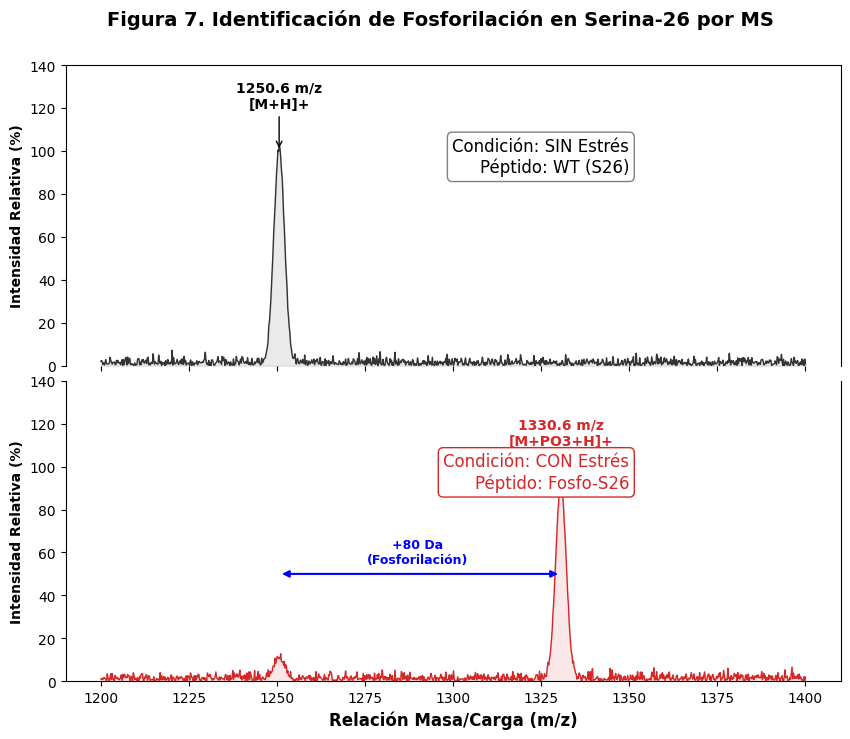

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
plt.subplots_adjust(hspace=0.05)


ax1.plot(mz_axis, signal_control, color='#333333', linewidth=1)
ax1.fill_between(mz_axis, signal_control, color='#333333', alpha=0.1)

ax1.annotate(f'{base_mass} m/z\n[M+H]+', xy=(base_mass, 100), xytext=(base_mass, 120),
             ha='center', arrowprops=dict(arrowstyle='->'), fontsize=10, fontweight='bold')
ax1.text(1350, 90, 'Condición: SIN Estrés\nPéptido: WT (S26)', ha='right', fontsize=12, color='black',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))

ax1.set_ylabel('Intensidad Relativa (%)', fontweight='bold')
ax1.set_ylim(0, 140)
ax1.spines['bottom'].set_visible(False)
ax1.tick_params(labelbottom=False)

ax2.plot(mz_axis, signal_stress, color='#d62728', linewidth=1)
ax2.fill_between(mz_axis, signal_stress, color='#d62728', alpha=0.1)

ax2.annotate(f'{phos_mass:.1f} m/z\n[M+PO3+H]+', xy=(phos_mass, 90), xytext=(phos_mass, 110),
             ha='center', arrowprops=dict(arrowstyle='->', color='#d62728'), fontsize=10, fontweight='bold', color='#d62728')

ax2.annotate('', xy=(base_mass, 50), xytext=(phos_mass, 50),
             arrowprops=dict(arrowstyle='<|-|>', color='blue', lw=1.5))
ax2.text(1290, 55, '+80 Da\n(Fosforilación)', ha='center', color='blue', fontsize=9, fontweight='bold')

ax2.text(1350, 90, 'Condición: CON Estrés\nPéptido: Fosfo-S26', ha='right', fontsize=12, color='#d62728',
         bbox=dict(facecolor='white', edgecolor='#d62728', boxstyle='round'))

ax2.set_ylabel('Intensidad Relativa (%)', fontweight='bold')
ax2.set_xlabel('Relación Masa/Carga (m/z)', fontweight='bold', fontsize=12)
ax2.set_ylim(0, 140)
ax2.spines['top'].set_visible(False)

plt.suptitle('Figura 7. Identificación de Fosforilación en Serina-26 por MS', y=0.95, fontsize=14, fontweight='bold')

plt.savefig('Figura7_MassSpec.png', dpi=300)
plt.show()